In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM

In [2]:
o = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='GeneralSbs')
ost = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='GeneralSt')
tf = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TFlight')
tc = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TContact')
e = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Elevation')
pw = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Power')
pc = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Pace')
rsi = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='RSI')
wpx = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='WPX')
wpy = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='WPY')
sw = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='StepWidth')
nj = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='NJ')
d = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='Distance')
tt = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TTotal')
tp = pd.read_excel('OptoJumpSorted.xlsx', sheet_name='TPoints')

In [3]:
#swap
tt.loc[:40, 'Test'] = 'final'
tt.loc[40:, 'Test'] = 'initial'

In [4]:
df_list = [tf, tc, e, pw, pc, rsi, wpx, wpy, sw, nj, d, tp]
melt_df_list = []
for df in df_list:
    df.loc[:,'Test'] = tt.loc[:,'Test']    #swap
    melt_df_list = melt_df_list + [pd.melt(df, id_vars=['Name','Test','Group','Sex','NJumps', 'Mean'], 
                                   value_vars=range(1,170), var_name='Jump', value_name='val')]

In [5]:
melt_df_list_timed = []
for df in melt_df_list:
    melt_df_timed = df.copy()
    melt_df_timed['time'] = melt_df_list[11].val
    melt_df_list_timed = melt_df_list_timed + [melt_df_timed]

In [6]:
values = ['Flight Time (s)', 'Contact Time (s)', 'Elevation (cm)', 'Propulsive Power (W/Kg)', 'Pace (jumps/s)', 'RSI (m/s)', 'StepWidth (mm)',
'Distance (cm)']
keys = [0, 1, 2, 3, 4, 5, 8, 10]
dict = {k: v for k, v in zip(keys, values)}
dict

{0: 'Flight Time (s)',
 1: 'Contact Time (s)',
 2: 'Elevation (cm)',
 3: 'Propulsive Power (W/Kg)',
 4: 'Pace (jumps/s)',
 5: 'RSI (m/s)',
 8: 'StepWidth (mm)',
 10: 'Distance (cm)'}

In [7]:
valori = ['timp in aer (s)', 'timp contact (s)', 'inaltime (cm)', 'putere (W/Kg)',
          'viteza (sarituri/s)', 'IFR (m/s)', 'distanta picioare (mm)', 'distanta deviere (cm)']
chei = [0, 1, 2, 3, 4, 5, 8, 10]
dict2 = {k: v for k, v in zip(chei, valori)}
dict2

{0: 'timp in aer (s)',
 1: 'timp contact (s)',
 2: 'inaltime (cm)',
 3: 'putere (W/Kg)',
 4: 'viteza (sarituri/s)',
 5: 'IFR (m/s)',
 8: 'distanta picioare (mm)',
 10: 'distanta deviere (cm)'}

Text(20.249999999999993, 0.5, 'Flight Time (s)')

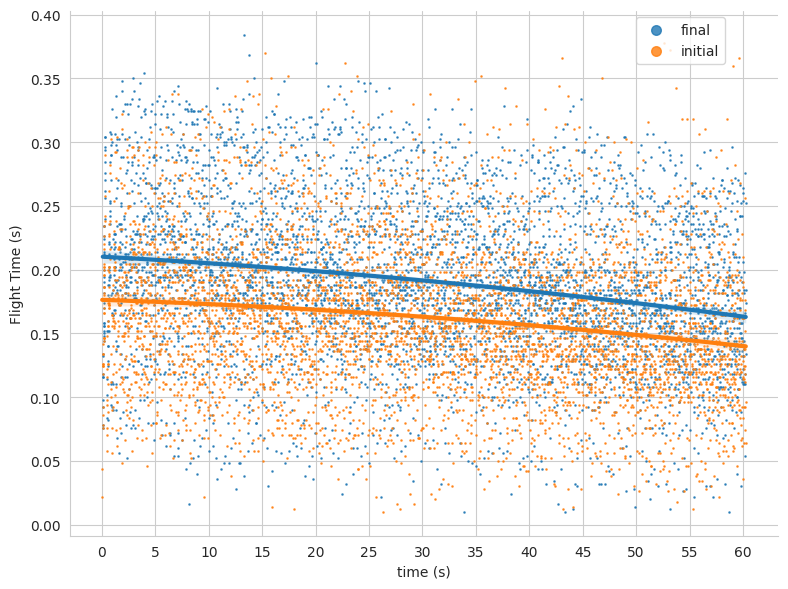

In [8]:
i=0
sns.set_style("whitegrid")
sns.lmplot(melt_df_list_timed[i].loc[melt_df_list_timed[i].val<0.4],
           x='time', y='val', hue='Test', order = 2, x_ci='sd', legend=False,
           scatter_kws={"s": 0.75}, line_kws={"lw": 3},
           height=6, aspect=1.33).set(xticks=range(0, 65, 5))
plt.legend(loc=[0.8,0.9], markerscale=8)
plt.xlabel('time (s)')
plt.ylabel(dict[i])
#plt.savefig(dict[i]+' regression.svg')

Text(0, 0.5, 'Flight Time (s)')

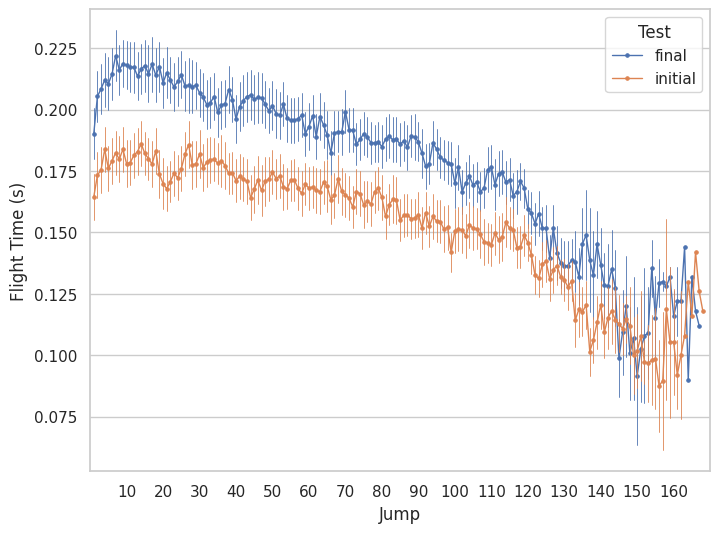

In [9]:
# Cannot use time because the function will attempt to aggregate all combinations, because time varies
# However NJump does not, so it can be aggregated
i=0
sns.set(rc={"figure.figsize":(8,6)})
sns.set_style("whitegrid")
sns.pointplot(melt_df_list_timed[i].loc[melt_df_list_timed[i].val<0.4],
              x='Jump', y='val', hue='Test',
              estimator='mean', errorbar='se', legend=True, lw = 1,
              err_kws={'linewidth': 0.6}).set(xticks=range(-1, 170, 10))
# plt.xticks(ticks=[], labels=[])
plt.ylabel(dict[i])
#plt.savefig(dict[i]+' mean.svg')

In [10]:
# i=2
# sns.set_style("whitegrid")
# sns.lmplot(melt_df_list_timed[i].loc[melt_df_list_timed[i].val<20],
#            x='time', y='val', hue='Test', order = 2, x_ci='sd', legend=False,
#            scatter_kws={"s": 0.75}, line_kws={"lw": 3},
#            height=6, aspect=1.33).set(xticks=range(0, 65, 5))
# plt.legend(loc=[0.8,0.9], markerscale=8)
# plt.xlabel('timp (s)')
# plt.ylabel(dict2[i])
# plt.savefig(dict2[i]+' - regresie.svg')
# plt.savefig('putere - regresie.svg')
# plt.savefig('viteza - regresie.svg')
# plt.savefig('IFR - regresie.svg')

In [11]:
# Cannot use time because the function will attempt to aggregate all combinations, because time varies
# However NJump does not, so it can be aggregated
# i=2
# sns.set(rc={"figure.figsize":(8,6)})
# sns.set_style("whitegrid")
# sns.pointplot(melt_df_list_timed[i].loc[melt_df_list_timed[i].val<20],
#               x='Jump', y='val', hue='Test',
#               estimator='mean', errorbar='se', legend=True, lw = 1,
#               err_kws={'linewidth': 0.6}).set(xticks=range(-1, 170, 10))
# plt.xlabel('saritura')
# # plt.xticks(ticks=[], labels=[])
# plt.ylabel(dict2[i])
# plt.savefig(dict2[i]+' - medie.svg')
# plt.savefig('putere - medie.svg')
# plt.savefig('viteza - medie.svg')
# plt.savefig('IFR - medie.svg')

In [12]:
wh = o.loc[:,['Name', 'Weight1', 'Height2']].copy()
wh.columns = ['Name', 'weight', 'height']

In [13]:
n = []
for df in melt_df_list_timed:
    ndf = df.copy()
    ndf = ndf.merge(wh, how='left')
    ndf.loc[:, 'bmi'] = 10000 * ndf.loc[:, 'weight'] / (ndf.loc[:, 'height']**2)
    ndf['nw'] = ndf.val.div(ndf.weight)
    ndf['nh'] = ndf.val.div(ndf.height)
    ndf['nbmi'] = ndf.val.div(ndf.bmi)
    n = n + [ndf]

Text(36.0, 0.5, 'Flight Time (s)')

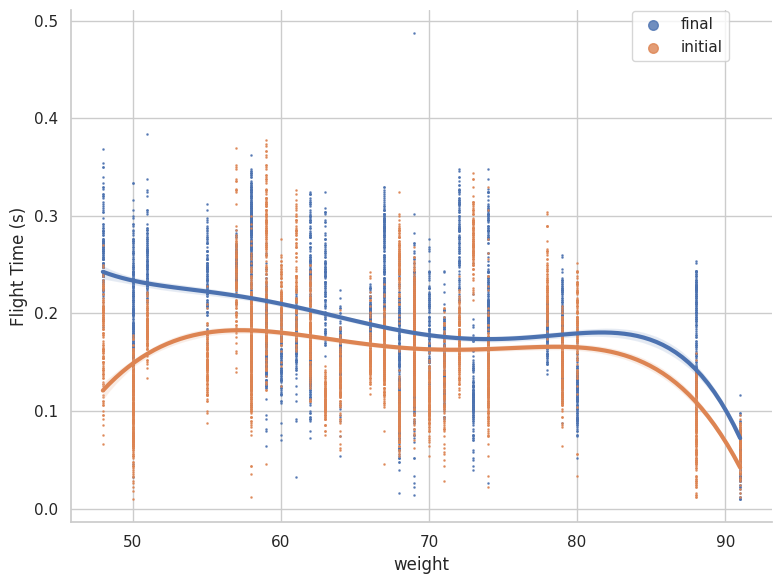

In [14]:
i=0
sns.set_style("whitegrid")
sns.lmplot(n[i],
           x='weight', y='val', hue='Test', order = 5, x_ci='sd', legend=False,
           scatter_kws={"s": 0.75}, line_kws={"lw": 3},
           height=6, aspect=1.33)
# .set(xticks=range(0, 65, 5))
plt.legend(loc=[0.8,0.9], markerscale=8)
# plt.xlabel('time (s)')
plt.ylabel(dict[i])
#plt.savefig(dict[i]+' regression.svg')

In [15]:
n[2].loc[n[2].val.isna()].groupby('Test').Jump.min()

Test
final      105
initial    115
Name: Jump, dtype: object

In [16]:
AnovaRM(data=n[2].loc[n[2].Jump<105], depvar='val', subject='Name', within=['Test','Jump']).fit().summary()

,F Value,Num DF,Den DF,Pr > F
Test,6.1358,1.0000,39.0000,0.0177
Jump,11.3422,103.0000,4017.0000,0.0000
Test:Jump,1.5427,103.0000,4017.0000,0.0004


In [17]:
model = smf.ols('val ~ Test * Jump', data = n[2])

In [18]:
print('TSS:    ', model.fit().centered_tss, '\nSSR:    ', model.fit().ssr, '\nESS:    ', model.fit().ess, sep='')

TSS:    84052.92563310919
SSR:    71533.91223809721
ESS:    12519.013395011978


In [19]:
print('Test:           ', model.fit().centered_tss - smf.ols('val ~ Test', data=n[2]).fit().ssr,
      '\nJump:           ', model.fit().centered_tss - smf.ols('val ~ Jump', data=n[2]).fit().ssr,
      '\nInteraction:    ', model.fit().ess - smf.ols('val ~ Test + Jump', data=n[2]).fit().ess, sep='')

Test:           4260.362348896553
Jump:           8041.539644442135
Interaction:    579.0071421790199


In [20]:
-model.fit().ssr / model.fit().centered_tss + 1
# R^2, coeff of determination

np.float64(0.1489420302828891)

In [21]:
model.fit().summary().tables[0]

Dep. Variable:,val,R-squared:,0.149
Model:,OLS,Adj. R-squared:,0.121
Method:,Least Squares,F-statistic:,5.357
Date:,"Sat, 06 Sep 2025",Prob (F-statistic):,3.96e-177
Time:,00:55:39,Log-Likelihood:,-25083.
No. Observations:,10559,AIC:,5.084e+04
Df Residuals:,10224,BIC:,5.327e+04
Df Model:,334,,
Covariance Type:,nonrobust,,


In [22]:
model_timed = smf.ols('val ~ time * Test', data=n[2])

In [23]:
print('TSS:    ', model_timed.fit().centered_tss,
      '\nSSR:    ', model_timed.fit().ssr,
      '\nESS:    ', model_timed.fit().ess, sep='')

TSS:    84052.92563310919
SSR:    76388.26366235543
ESS:    7664.661970753761


In [24]:
print('Test:           ', model_timed.fit().centered_tss - smf.ols('val ~ Test', data=n[2]).fit().ssr,
      '\ntime:           ', model_timed.fit().centered_tss - smf.ols('val ~ time', data=n[2]).fit().ssr,
      '\nInteraction:    ', model_timed.fit().ess - smf.ols('val ~ Test + time', data=n[2]).fit().ess, sep='')

Test:           4260.362348896553
time:           3159.3087177167763
Interaction:    180.86365564048174


In [25]:
model_timed.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    val   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     353.0
Date:                Sat, 06 Sep 2025   Prob (F-statistic):          1.74e-218
Time:                        00:55:47   Log-Likelihood:                -25430.
No. Observations:               10559   AIC:                         5.087e+04
Df Residuals:                   10555   BIC:                         5.090e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                6.0703      0.075     80.513      0.000       5.922       6.218
Test[T.initial]         -1.7374      0.105    -16.484      0.000      -1.944      -1.531
time                    -0.0395      0.002    -18.368      0.000      -0.044      -0.035
time:Test[T.initial]     0.0151      0.003      4.999      0.000       0.009       0.021
==============================================================================
Omnibus:                     2002.812   Durbin-Watson:                   1.957
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4057.587
Skew:                           1.135   Prob(JB):                         0.00
Kurtosis:                       5.018   Cond. No.                         185.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [26]:
pd.DataFrame(model_timed.exog)
# using '*' in the ols formula introduces the interaction term in the last column, a product of columns 1 and 2

,0,1,2,3
0,1.0,0.0,0.262,0.000
1,1.0,0.0,0.226,0.000
2,1.0,0.0,0.294,0.000
3,1.0,0.0,0.304,0.000
4,1.0,0.0,0.304,0.000
...,...,...,...,...
10554,1.0,0.0,59.724,0.000
10555,1.0,1.0,59.418,59.418
10556,1.0,0.0,60.080,0.000
10557,1.0,1.0,59.790,59.790


In [27]:
smf.ols('val ~ time + weight + Test + Group', data = n[2]).fit(cov_type='HC0').summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    val   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     688.4
Date:                Sat, 06 Sep 2025   Prob (F-statistic):               0.00
Time:                        00:55:54   Log-Likelihood:                -24754.
No. Observations:               10559   AIC:                         4.952e+04
Df Residuals:                   10554   BIC:                         4.955e+04
Df Model:                           4                                         
Covariance Type:                  HC0                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          10.1181      0.167     60.473      0.000       9.790      10.446
Test[T.initial]    -1.3232      0.049    -26.905      0.000      -1.420      -1.227
Group[T.J]          0.9442      0.052     18.057      0.000       0.842       1.047
time               -0.0320      0.001    -22.649      0.000      -0.035      -0.029
weight             -0.0692      0.002    -31.200      0.000      -0.074      -0.065
==============================================================================
Omnibus:                     2147.430   Durbin-Watson:                   2.039
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4651.253
Skew:                           1.180   Prob(JB):                         0.00
Kurtosis:                       5.238   Cond. No.                         547.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC0)
"""

In [28]:
zn2 = n[2].copy()

In [29]:
zn2 = zn2.select_dtypes(include=[np.number]).dropna().apply(st.zscore)

In [30]:
smf.ols('val ~ time + weight', data = zn2).fit(cov_type='HC1').summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    val   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     742.8
Date:                Sat, 06 Sep 2025   Prob (F-statistic):          1.48e-302
Time:                        00:55:59   Log-Likelihood:                -14307.
No. Observations:               10559   AIC:                         2.862e+04
Df Residuals:                   10556   BIC:                         2.864e+04
Df Model:                           2                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    4.12e-17      0.009   4.51e-15      1.000      -0.018       0.018
time          -0.1953      0.009    -21.423      0.000      -0.213      -0.177
weight        -0.2873      0.009    -31.933      0.000      -0.305      -0.270
==============================================================================
Omnibus:                     1978.774   Durbin-Watson:                   1.890
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4004.694
Skew:                           1.123   Prob(JB):                         0.00
Kurtosis:                       5.015   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""